In [1]:
import tensorflow as tf
import keras
import cv2
import os
import PIL
import numpy as np
import pandas as pd
from skimage import io
import matplotlib.pyplot as plt
import pathlib
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [2]:
# inspired by Kaggle: https://www.kaggle.com/code/sirajamsamira/1-1-retinal-eye-disease-classifier
path=pathlib.Path(r'/Users/JMSaadon/Downloads/dataset')
path

PosixPath('/Users/JMSaadon/Downloads/dataset')

In [3]:
# inspired by Kaggle: https://www.kaggle.com/code/sirajamsamira/1-1-retinal-eye-disease-classifier
normal = np.array(list(path.glob('normal/*')))
glaucoma = np.array(list(path.glob('glaucoma/*')))
diabetic_retinopathy = np.array(list(path.glob('diabetic_retinopathy/*')))
cataract = np.array(list(path.glob('cataract/*')))

In [4]:
# disease labels as numbers
normal_label = 0
glaucoma_label = 1
diabetic_retinopathy_label = 2
cataract_label = 3

# disease dfs
normal_df = pd.DataFrame({'image': normal, 'disease': normal_label})
glaucoma_df = pd.DataFrame({'image': glaucoma, 'disease': glaucoma_label})
diabetic_retinopathy_df = pd.DataFrame({'image': diabetic_retinopathy, 'disease': diabetic_retinopathy_label})
cataract_df = pd.DataFrame({'image': cataract, 'disease': cataract_label})

# append all dfs to eyes
eyes = pd.DataFrame(columns=['image','disease'])
eyes = pd.concat([normal_df, glaucoma_df, diabetic_retinopathy_df, cataract_df], ignore_index=True)


X = []
y = []

# reformat img paths to become the actual images
# inspired by Kaggle: https://www.kaggle.com/code/sirajamsamira/1-1-retinal-eye-disease-classifier
for i in range(len(eyes)):
    path = eyes['image'][i]
    img = cv2.imread(str(path))
    resize = cv2.resize(img, (256, 256))
    # eyes['image'][i] = resize
    X.append(resize)
    y.append(eyes['disease'][i])

eyes

,image,disease
0,/Users/JMSaadon/Downloads/dataset/normal/3407_...,0
1,/Users/JMSaadon/Downloads/dataset/normal/3294_...,0
2,/Users/JMSaadon/Downloads/dataset/normal/2547_...,0
3,/Users/JMSaadon/Downloads/dataset/normal/3010_...,0
4,/Users/JMSaadon/Downloads/dataset/normal/2895_...,0
...,...,...
4212,/Users/JMSaadon/Downloads/dataset/cataract/_55...,3
4213,/Users/JMSaadon/Downloads/dataset/cataract/_38...,3
4214,/Users/JMSaadon/Downloads/dataset/cataract/_25...,3
4215,/Users/JMSaadon/Downloads/dataset/cataract/477...,3


In [5]:
X = np.array(X)
y = np.array(y)

# separate to train and test
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# fix data type
X_train_full = X_train_full.astype('float32')
X_test = X_test.astype('float32')

# normalization (part of data preparation)
X_train_full, X_test = X_train_full / 255.0, X_test / 255.0

# since test set was .1, I made the validation set .1 as well by getting the size of the test set 
# and subtracting it from the total dataset size to get 3373
X_train, X_valid = X_train_full[:3373], X_train_full[3373:]
y_train, y_valid = y_train_full[:3373], y_train_full[3373:]


In [21]:
# CNN creation
model4 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='relu')
])
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model4.compile(optimizer='Adam',
              loss=loss_fn,
              metrics=['accuracy'])
history = model4.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=15,
    validation_data=(X_valid, y_valid),
)

/Users/JMSaadon/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.4013 - loss: 2.6088 - val_accuracy: 0.6635 - val_loss: 0.8396
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 51s 956ms/step - accuracy: 0.6454 - loss: 0.7948 - val_accuracy: 0.7204 - val_loss: 0.6852
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 49s 911ms/step - accuracy: 0.7221 - loss: 0.6577 - val_accuracy: 0.7370 - val_loss: 0.6531
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 984ms/step - accuracy: 0.7516 - loss: 0.6064 - val_accuracy: 0.7678 - val_loss: 0.6023
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 49s 921ms/step - accuracy: 0.7804 - loss: 0.5485 - val_accuracy: 0.7607 - val_loss: 0.5633
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 50s 936ms/step - accuracy: 0.7866 - loss: 0.5062 - val_accuracy: 0.7867 - val_loss: 0.5332
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 49s 921ms/step - accuracy: 0.7955 - loss: 0.4977 - val_accuracy: 0.8057 - val_loss: 0.4978
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 49s 925ms/step - accuracy: 0.8244 - loss: 0.4504 - val_accurac

In [17]:
model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 230400)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    29,491,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,646,816 (338.16 MB)

 Trainable params: 29,548,938 (112.72 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,097,878 (225.44 MB)

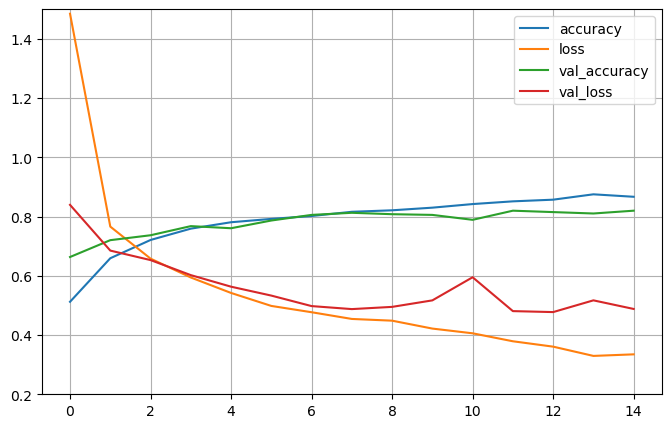

In [23]:
# visualization: taken from lecture 14
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0.2, 1.5) # set the vertical range to [0-1]
plt.show()

In [24]:
model4.evaluate(X_test, y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.8420 - loss: 0.4707


[0.5128257274627686, 0.8388625383377075]

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step


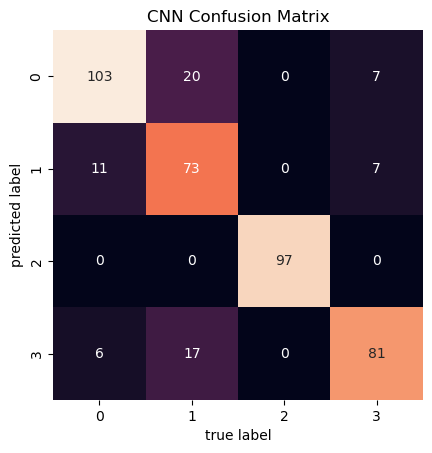

In [28]:
from sklearn.metrics import classification_report
import seaborn as sns
from sklearn.metrics import confusion_matrix

# confusion matrix
prediction = model4.predict(X_test)
mat = confusion_matrix(y_test, np.argmax(prediction,axis=1))
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.title('CNN Confusion Matrix')
plt.ylabel('predicted label');

In [35]:
# defining new train/test split since there is now no validation set
new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fix data type
new_X_train = new_X_train.astype('float32')
new_X_test = new_X_test.astype('float32')

# normalization (part of data preparation)
new_X_train, new_X_test = new_X_train / 255.0, new_X_test / 255.0

# flattened to fit into the new models
flat_new_X_train = new_X_train.reshape(new_X_train.shape[0], -1)
flat_new_X_test = new_X_test.reshape(new_X_test.shape[0], -1)

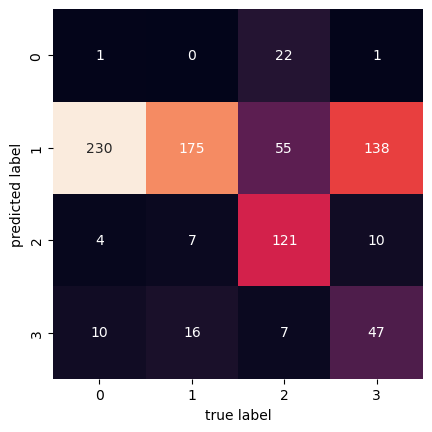

In [36]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

modelNB= GaussianNB().fit(flat_new_X_train, new_y_train)
predNB = modelNB.predict(flat_new_X_test)
mat = confusion_matrix(new_y_test, predNB)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [38]:
# accuracy
modelNB.score(flat_new_X_test,new_y_test)

0.4075829383886256

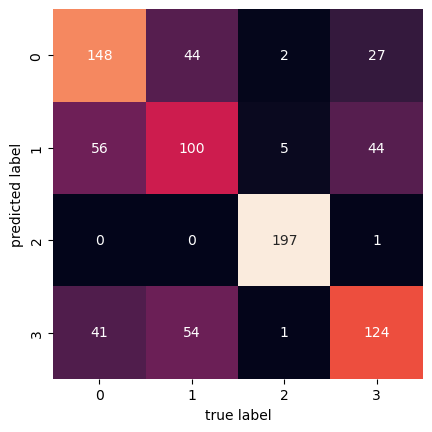

In [39]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier as DTC

modelDT = DTC(random_state=42).fit(flat_new_X_train, new_y_train)
predDT = modelDT.predict(flat_new_X_test)
mat = confusion_matrix(new_y_test, predDT)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [42]:
# accuracy
modelDT.score(flat_new_X_test,new_y_test)

0.6741706161137441

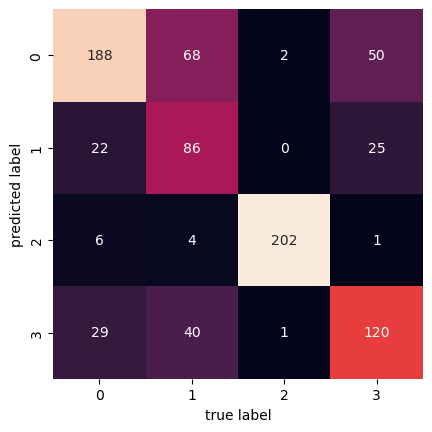

In [44]:
# KNN
from sklearn.neighbors import KNeighborsClassifier as KNN
modelKNN = KNN(n_neighbors=10)
modelKNN.fit(flat_new_X_train, new_y_train)
predKNN = modelKNN.predict(flat_new_X_test)
mat = confusion_matrix(new_y_test, predKNN)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [45]:
# accuracy
modelKNN.score(flat_new_X_test,new_y_test)

0.7061611374407583